https://machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/

In [4]:
# Configs
# aggregation level
#agg = 'D'
agg = 'W'
#agg = 'ME'

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [6]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

In [7]:

# load the car sales dataset
#from pandas import read_csv
# load data
#path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
#df = read_csv(path, header=0)

df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
# summarize shape
print(df.shape)
# show first few rows
print(df.head(1))


(4017, 20)
        Date  Tmax °C  Tmin °C  Daily Tmean °C Daily range degC Grass min °C  \
0 2015-01-01     13.5      2.6             8.1             10.9            0   

   Air frost 0/1  Ground frost 0/1  Max ≥ 25.0°C  Max ≥ 30.0°C  Min ≥ 15.0 °C  \
0              0               0.0             0             0              0   

   Max < 0 °C Rainfall mm raw incl traces  Rainfall mm 1 dpl no traces  \
0           0                         0.9                          0.9   

   Rain day (0.2 mm or more)  Wet day (1.0 mm or more)  Sunshine duration h  \
0                          1                         0                  0.0   

   Nil sunshine  12 h sunshine  Incident_Count  
0             1              0               3  


In [8]:
print(df['Date'].head(2))
print('.  .... ..   ....')
print('.  .... ..   ....')
print(df['Date'].tail(2))

0   2015-01-01
1   2015-01-02
Name: Date, dtype: datetime64[us]
.  .... ..   ....
.  .... ..   ....
4015   2025-12-29
4016   2025-12-30
Name: Date, dtype: datetime64[us]


Text(0.5, 1.0, 'Incident_Count: Daily Aggregation')

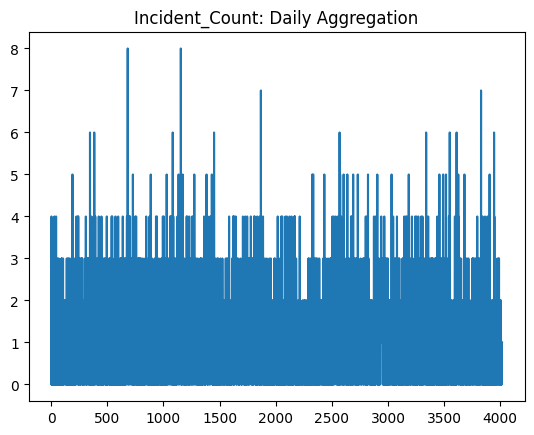

In [9]:
# plot the time series
df['Incident_Count'].plot()
plt.title('Incident_Count: Daily Aggregation')

In [10]:
...
# prepare expected column names
#df = df[['Date','Incident_Count']]

df.rename(columns={'Date': 'ds' }, inplace = True)
df.rename(columns={'Incident_Count': 'y' }, inplace = True)
df['ds']= pd.to_datetime(df['ds'])


df = df[['ds', 'y']]
df['ds']= pd.to_datetime(df['ds'])
df.head(5)


,ds,y
0,2015-01-01,3
1,2015-01-02,0
2,2015-01-03,0
3,2015-01-04,4
4,2015-01-05,2


Make an In-Sample Forecast

It can be useful to make a forecast on historical data.

That is, we can make a forecast on data used as input to train the model. Ideally, the model has seen the data before and would make a perfect prediction.

Nevertheless, this is not the case as the model tries to generalize across all cases in the data.

This is called making an in-sample (in training set sample) forecast and reviewing the results can give insight into how good the model is. That is, how well it learned the training data.

A forecast is made by calling the predict() function and passing a DataFrame that contains one column named ‘ds‘ and rows with date-times for all the intervals to be predicted.

There are many ways to create this “forecast” DataFrame. In this case, we will loop over one year of dates, e.g. the last 12 months in the dataset, and create a string for each month. We will then convert the list of dates into a DataFrame and convert the string values into date-time objects.

In [11]:
df = df.resample(rule=agg, on='ds')['y'].sum()
df.head(2)


ds
2015-01-04    7
2015-01-11    7
Freq: W-SUN, Name: y, dtype: int64

Text(0, 0.5, 'Freq')

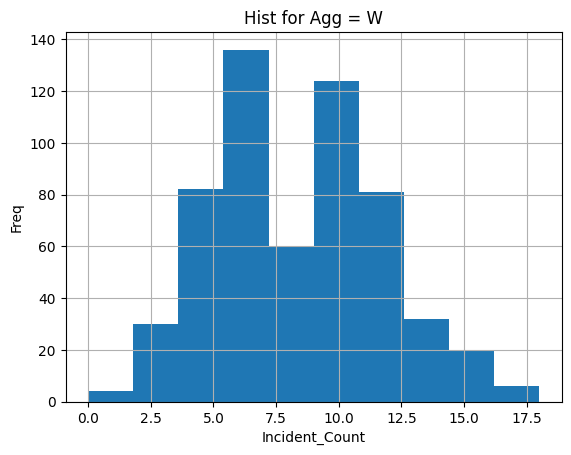

In [12]:
df.hist()
plt.title(f'Hist for Agg = {agg}')
plt.xlabel('Incident_Count')
plt.ylabel('Freq')

Text(0.5, 1.0, 'Boxplot for Agg = W')

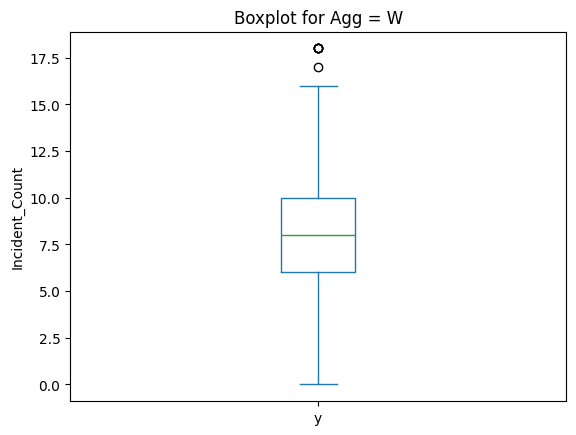

In [14]:
df.plot.box()
plt.ylabel('Incident_Count')
plt.title(f'Boxplot for Agg = {agg}')

## Feature Correlations

## Since this code work with just columns 'ds' and 'y', where does the features come into it?

In [15]:
df.info()

<class 'pandas.Series'>
DatetimeIndex: 575 entries, 2015-01-04 to 2026-01-04
Freq: W-SUN
Series name: y
Non-Null Count  Dtype
--------------  -----
575 non-null    int64
dtypes: int64(1)
memory usage: 9.0 KB


In [16]:
df = pd.DataFrame(data= df)
df = df.reset_index()

In [17]:
df.head(4)

,ds,y
0,2015-01-04,7
1,2015-01-11,7
2,2015-01-18,7
3,2015-01-25,8


Text(0.5, 1.0, 'Incident_Count:Agg = W')

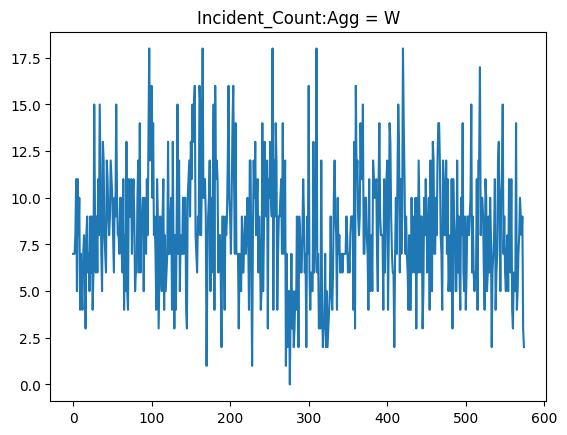

In [18]:
# plot the time series
df['y'].plot()
plt.title(f'Incident_Count:Agg = {agg}')

In [19]:
import pandas as pd

# Generate the range (inclusive by default)
# date list DAILY AGGREGATION
#date_list = pd.date_range(start="2015-01-01", end="2025-12-30", freq="D")

# date list WEEKLY AGGREGATION
date_list = pd.date_range(start="2015-01-01", end="2025-12-30", freq=agg)
# Convert to a standard Python list of timestamps
date_list = date_list.tolist()
date_list = pd.DataFrame(date_list)
print(f"Total dates generated: {len(date_list)}")
date_list.head(3)

Total dates generated: 574


,0
0,2015-01-04
1,2015-01-11
2,2015-01-18


In [20]:
#future_dates = pd.date_range(start="2024-01-01", end="2026-01-01", freq="D")
future_dates = pd.date_range(start="2024-01-01", end="2026-01-01", freq=agg)
# Convert to a standard Python list of timestamps
future_date_list = future_dates.tolist()

#print(f"Total dates generated: {len(future_date_list)}")

future_date_list = pd.DataFrame(future_date_list)
#future_date_list= pd.to_datetime(future_date_list)
future_date_list.head(3)

,0
0,2024-01-07
1,2024-01-14
2,2024-01-21


In [21]:
# define the model
model = Prophet()
# fit the model
model.fit(df)

12:05:25 - cmdstanpy - INFO - Chain [1] start processing
12:05:25 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future_date_list = pd.DataFrame(future_date_list)
future_date_list.columns = ['ds']
future_date_list['ds']= pd.to_datetime(future_date_list['ds'])
future_date_list.shape

(104, 1)

In [23]:
forecast = model.predict(future_date_list) 
forecast.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-07,7.932815,2.746437,10.083576,7.932815,7.932815,-1.509806,-1.509806,-1.509806,-1.509806,-1.509806,-1.509806,0.0,0.0,0.0,6.423009
1,2024-01-14,7.930944,3.561836,11.603708,7.930944,7.930944,-0.375816,-0.375816,-0.375816,-0.375816,-0.375816,-0.375816,0.0,0.0,0.0,7.555127
2,2024-01-21,7.929072,5.048994,12.750766,7.929072,7.929072,1.036639,1.036639,1.036639,1.036639,1.036639,1.036639,0.0,0.0,0.0,8.965711


In [24]:
...
# summarize the forecast
print('Head')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print(50*'|')
print('\nTail')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Head
          ds      yhat  yhat_lower  yhat_upper
0 2024-01-07  6.423009    2.746437   10.083576
1 2024-01-14  7.555127    3.561836   11.603708
2 2024-01-21  8.965711    5.048994   12.750766
3 2024-01-28  9.352994    5.627463   13.227134
4 2024-02-04  8.584732    4.670128   12.381492
||||||||||||||||||||||||||||||||||||||||||||||||||

Tail
            ds       yhat  yhat_lower  yhat_upper
99  2025-11-30  10.959663    7.479815   14.689007
100 2025-12-07  11.989226    8.183630   15.835287
101 2025-12-14  11.575599    7.458132   15.583159
102 2025-12-21   9.602105    5.484074   13.270938
103 2025-12-28   7.273178    2.990475   11.298507


Text(0.5, 1.0, 'Agg = W')

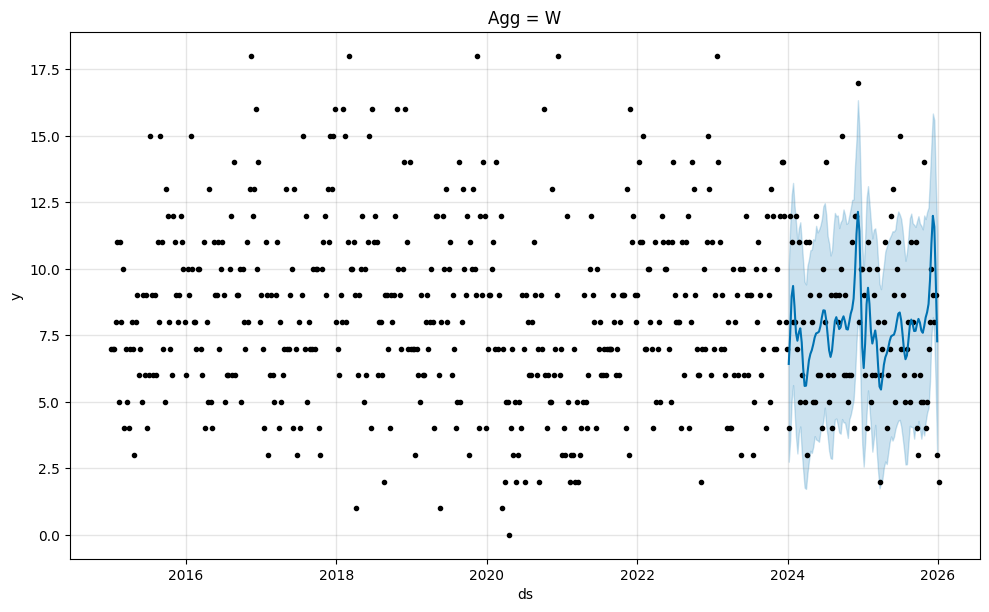

In [27]:

model.plot(forecast)
plt.title(f'Agg = {agg}')

Make an Out-of-Sample Forecast
In practice, we really want a forecast model to make a prediction beyond the training data.

This is called an out-of-sample forecast.

We can achieve this in the same way as an in-sample forecast and simply specify a different forecast period.

In this case, a period beyond the end of the training dataset, starting 2027-01.

Manually Evaluate Forecast Model
It is critical to develop an objective estimate of a forecast model’s performance.

This can be achieved by holding some data back from the model, such as the last 12 months. Then, fitting the model on the first portion of the data, using it to make predictions on the held-pack portion, and calculating an error measure, such as the mean absolute error across the forecasts. E.g. a simulated out-of-sample forecast.

The score gives an estimate of how well we might expect the model to perform on average when making an out-of-sample forecast.

We can do this with the samples data by creating a new DataFrame for training with the last 12 months removed.

In [28]:
train = pd.date_range(start="2015-01-01", end="2026-01-01", freq=agg)
...
# create test dataset, remove last 12 months
#train = df.drop(df.index[-12:])
train
#print(train.tail())

DatetimeIndex(['2015-01-04', '2015-01-11', '2015-01-18', '2015-01-25',
               '2015-02-01', '2015-02-08', '2015-02-15', '2015-02-22',
               '2015-03-01', '2015-03-08',
               ...
               '2025-10-26', '2025-11-02', '2025-11-09', '2025-11-16',
               '2025-11-23', '2025-11-30', '2025-12-07', '2025-12-14',
               '2025-12-21', '2025-12-28'],
              dtype='datetime64[us]', length=574, freq='W-SUN')

In [29]:
# A forecast can then be made on the last 12 months of date-times.

# We can then retrieve the forecast values and the expected values from the original dataset 
# and calculate a mean absolute error metric using the scikit-learn library.

In [31]:
# calculate MAE between expected and predicted values for december

# mae = mean_absolute_error(results["y"], results["yhat"])
# rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

y_true = df['y'][-len(future_date_list):].values
#y_true = df['y'].values
y_pred = forecast['yhat'].values.round()
#mae = mean_absolute_error(y_true, y_pred)
#print('MAE: %.3f' % mae)
y_true, y_pred

(array([12, 11,  8,  8, 12,  7, 11,  5,  6,  8,  5, 11,  3, 11,  9,  8,  5,
         5, 12,  6,  9,  6,  4, 10,  8, 14,  6,  5,  9,  4,  6,  9,  9,  8,
         9, 10, 15,  6,  9,  6,  5,  6,  6, 11,  4, 12, 12, 17,  8, 10, 10,
         9,  6,  4, 11, 10,  5,  6,  9,  6, 10,  8,  2,  6,  7,  8, 11,  4,
         6,  7, 12, 13,  9,  5, 10, 11, 15,  7,  9,  6,  5,  7,  8,  5, 11,
         8,  6, 11,  4,  3,  6,  5,  5, 14,  4,  5,  7,  8, 10,  9,  8,  9,
         3,  2]),
 array([ 6.,  8.,  9.,  9.,  9.,  8.,  7.,  8.,  8.,  7.,  6.,  6.,  6.,
         6.,  7.,  7.,  7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  7.,  7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  9., 10., 11., 12., 11.,  9.,  7.,
         6.,  7.,  9.,  9.,  9.,  8.,  7.,  7.,  8.,  7.,  6.,  6.,  5.,
         6.,  6.,  7.,  7.,  7.,  7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  7.,  7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8

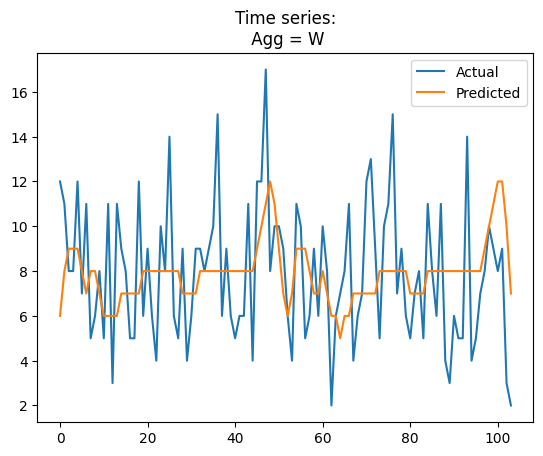

In [37]:
# plot expected vs actual
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title(f'Time series:\n Agg = {agg}')
plt.show()

Make an Out-of-Sample Forecast In practice, we really want a forecast model to make a prediction beyond the training data.

This is called an out-of-sample forecast.

We can achieve this in the same way as an in-sample forecast and simply specify a different forecast period.

In this case, a period beyond the end of the training dataset, starting 2027-01.

          ds      yhat  yhat_lower  yhat_upper
0 2025-01-05  6.267459    2.579927   10.067654
1 2025-01-12  7.188337    3.382180   11.284855
2 2025-01-19  8.665031    4.878612   12.688856
3 2025-01-26  9.285746    5.292244   13.230649
4 2025-02-02  8.673956    4.665480   12.575343


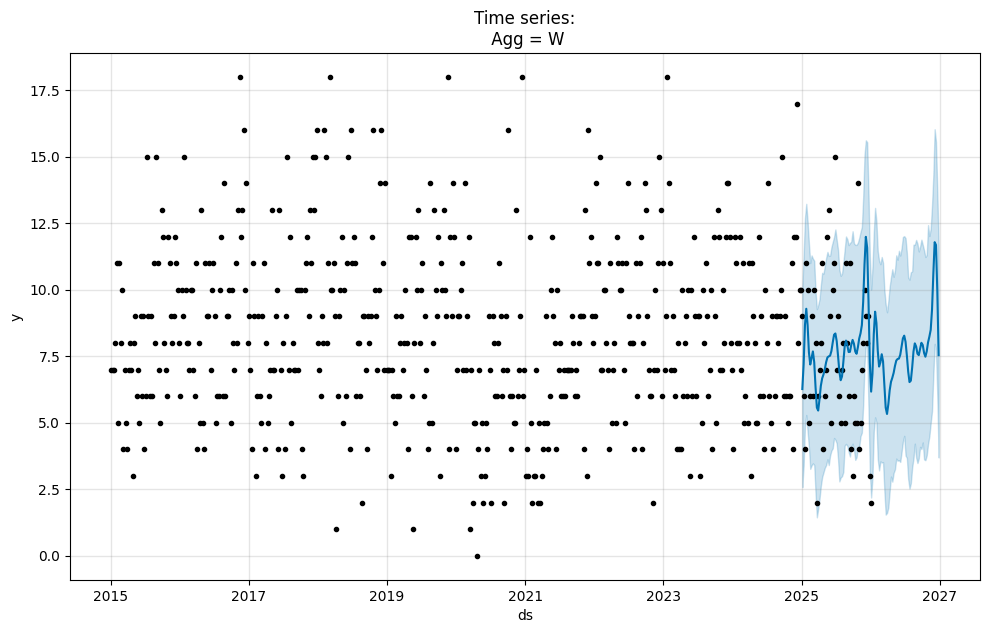

In [38]:
# define the period for which we want a prediction
#future_dates = pd.date_range(start="2024-01-01", end="2027-01-01", freq="D")
future_dates = pd.date_range(start="2025-01-01", end="2027-01-01", freq= agg)
# Convert to a standard Python list of timestamps
future = future_dates.tolist()

#print(f"Total dates generated: {len(future_date_list)}")

future = pd.DataFrame(future)

#future = DataFrame(future)
future.columns = ['ds']
future['ds']= pd.to_datetime(future['ds'])
# use the model to make a forecast
forecast = model.predict(future)
# summarize the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
# plot forecast
model.plot(forecast)

plt.title(f'Time series:\n Agg = {agg}')
plt.show()